# PIECEWISE PREDICTIONS

In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import os
import pandas as pd  # type: ignore
from timecourse_iterator import TimecourseIterator # type: ignore
from typing import Optional, cast, List, Union

import src.constants as cn
from src.system_discovery import SystemDiscovery
from src.piecewise_system_discovery import PiecewiseSystemDiscovery
from src.model import Model
from src.timecourse import Timecourse
from src.system_discovery_changepoint_detector import SystemDiscoveryChangepointDetector

# Individual models

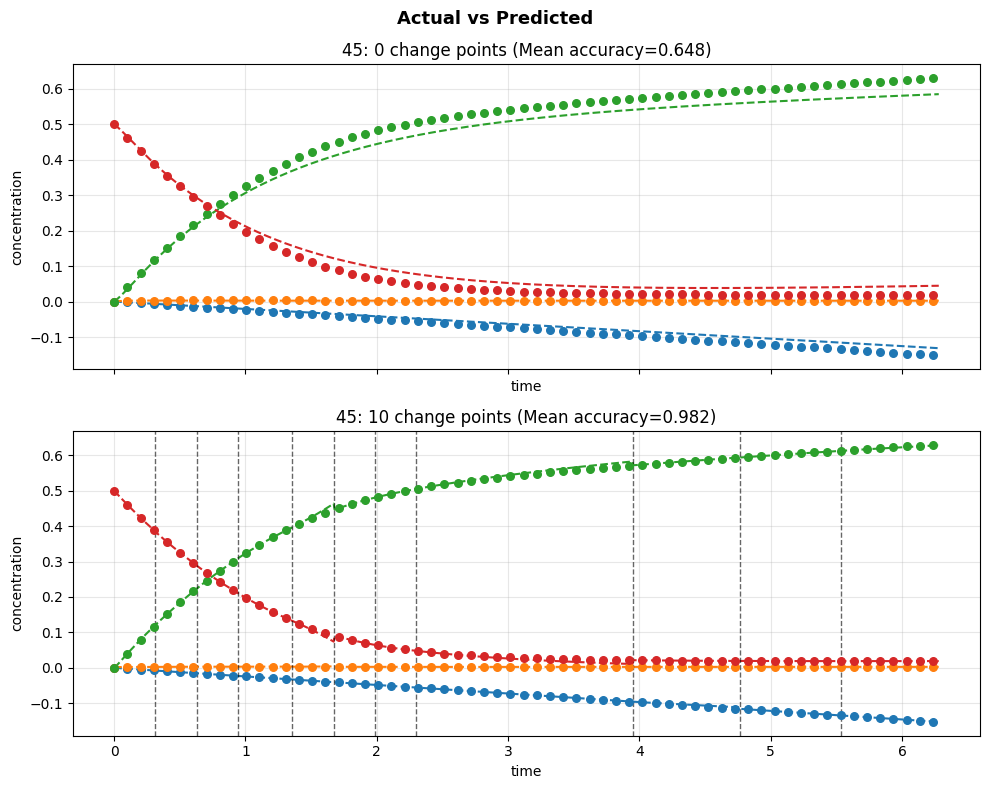

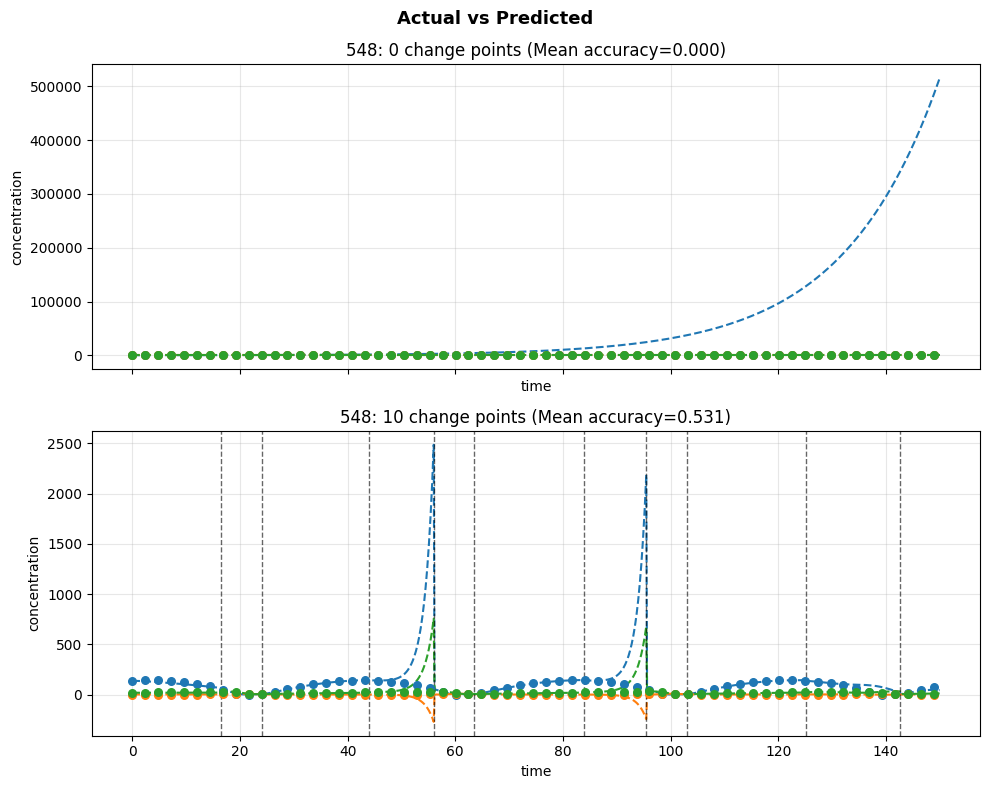

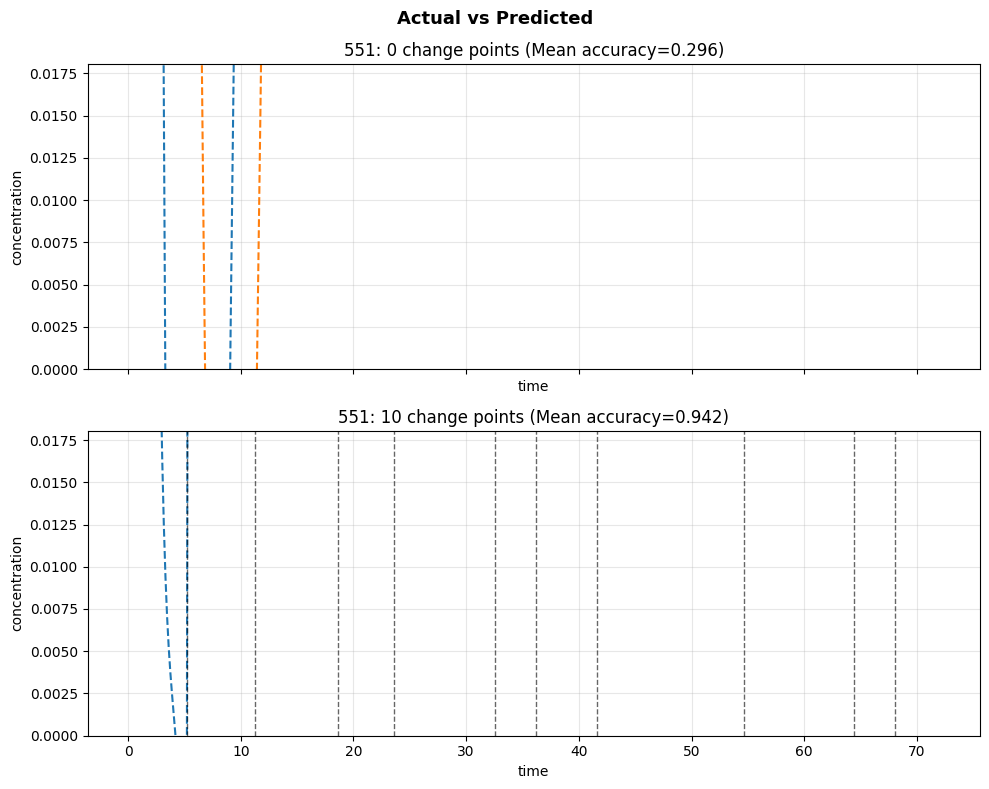

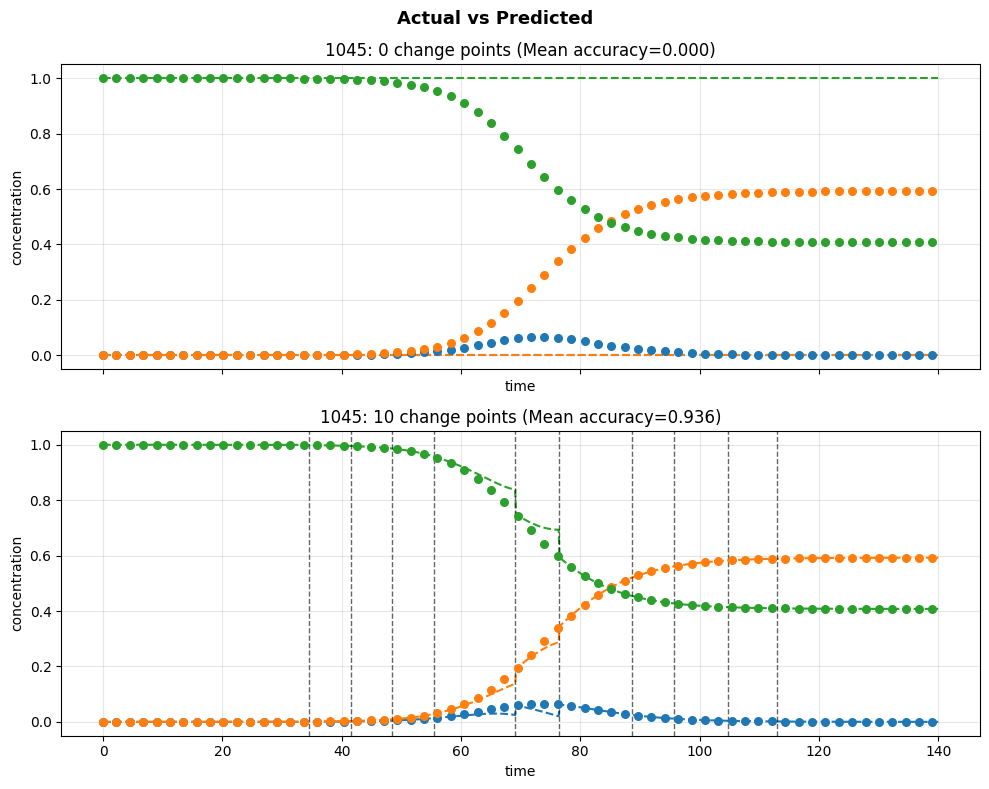

In [2]:
for model_num in [45, 548, 551, 1045]:
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, num_point =1000)
    df = timecourse.timecourse_df
    try:
        psd = PiecewiseSystemDiscovery(df, max_changepoint=10, min_segment_length=50,
                                        min_fractional_reduction=0.000, model_name=str(model_num))
        psd.fit()
        result = psd.plotPiecewise(legend=False, num_true_point=60)
    except Exception as e:
        print(f"Could not process {model_num}: {e}")

# CDFs

In [7]:
threshold = 0.001
path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{threshold}.csv")
DF = pd.read_csv(path)
DF.columns

Index(['system_id', 'aggregation_type', 'mean', 'min', 'max', 'count',
       'invalid_count', 'p05', 'p10', 'p20', 'p25', 'p30', 'p50', 'p80', 'p90',
       'p95', 'p99', 'max_changepoint', 'min_segment_length',
       'min_fractional_reduction', 'is_random_changepoints',
       'coefficient_threshold'],
      dtype='str')

In [4]:
cn.COL_AGGREGATION_TYPE_MODEL

'model'

In [8]:
def getDF(df: pd.DataFrame, is_species: bool = True, is_random: bool = False, max_changepoint: int = 10) -> pd.DataFrame:
    if is_species:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL]
    else:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL]
    if is_random:
        result_df = result_df[result_df[cn.COL_IS_RANDOM_CHANGPOINTS] == True]
    else:
        result_df = result_df[result_df[cn.COL_IS_RANDOM_CHANGPOINTS] == False]
    result_df = result_df[result_df[cn.COL_MAX_CHANGEPOINT] == max_changepoint]
    return result_df

# Tests
df = getDF(DF)
df

1        False
2        False
3        False
4        False
5        False
         ...  
39749    False
39754    False
39755    False
39760     True
39761     True
Name: max_changepoint, Length: 18199, dtype: bool